# End-to-End Modeling Flow
1. Install dependencies
2. Load raw Excel data
3. Check nulls and duplicates
4. Clean and preprocess data
5. Encode categorical features
6. Train-test split and feature scaling
7. Train 3 models (Logistic Regression, Random Forest, XGBoost)
8. Evaluate and compare models
9. Analyze feature importance and churn probabilities

In [117]:
# from pathlib import Path
# import pandas as pd

# # Build path relative to this notebook: ml/model.ipynb -> data/raw/*.xlsx
# data_path = Path.cwd().parent / "data" / "raw" / "E Commerce Dataset.xlsx"
# if not data_path.exists():
#     raise FileNotFoundError(f"Dataset not found at: {data_path}")

# # Inspect workbook and choose the most likely data sheet (usually the one with most rows).
# xls = pd.ExcelFile(data_path)
# sheet_candidates = []
# for sheet in xls.sheet_names:
#     temp = pd.read_excel(data_path, sheet_name=sheet)
#     sheet_candidates.append((sheet, temp.shape[0], temp.shape[1]))

# sheet_summary = pd.DataFrame(sheet_candidates, columns=["sheet", "rows", "cols"])
# best_sheet = sheet_summary.sort_values(["rows", "cols"], ascending=False).iloc[0]["sheet"]
# print("Available sheets:")
# display(sheet_summary)
# print(f"Selected sheet for modeling: {best_sheet}")

# # Load selected data sheet
# df = pd.read_excel(data_path, sheet_name=best_sheet)
# print(f"Loaded data shape: {df.shape}")
# display(df.head())

# # -------- Preprocessing --------
# df_processed = df.copy()

# # 1) Drop fully empty rows/columns
# df_processed = df_processed.dropna(how="all").dropna(axis=1, how="all")

# # 2) Normalize column names
# df_processed.columns = (
#     df_processed.columns.astype(str)
#     .str.strip()
#     .str.lower()
#     .str.replace(r"[^a-z0-9]+", "_", regex=True)
#     .str.strip("_")
# )

# # 3) Remove duplicate rows
# df_processed = df_processed.drop_duplicates().reset_index(drop=True)

# # 4) Trim whitespace in text columns
# text_cols = df_processed.select_dtypes(include=["object", "string"]).columns
# for col in text_cols:
#     df_processed[col] = df_processed[col].astype("string").str.strip()
#     df_processed[col] = df_processed[col].replace({"": pd.NA})

# # 5) Fill missing values
# num_cols = df_processed.select_dtypes(include=["number"]).columns
# cat_cols = df_processed.select_dtypes(exclude=["number"]).columns

# for col in num_cols:
#     df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# for col in cat_cols:
#     mode_values = df_processed[col].mode(dropna=True)
#     if not mode_values.empty:
#         df_processed[col] = df_processed[col].fillna(mode_values.iloc[0])

# print(f"Processed data shape: {df_processed.shape}")
# print("Top missing-value counts after preprocessing:")
# display(df_processed.isna().sum().sort_values(ascending=False).head(10))

# display(df_processed.head())

In [143]:
from pathlib import Path
import sqlite3
import pandas as pd

# Load modeling data from SQLite warehouse (gold layer).
db_path_candidates = [
    Path.cwd() / "data" / "gold" / "warehouse.db",
    Path.cwd().parent / "data" / "gold" / "warehouse.db",
]
db_path = next((p for p in db_path_candidates if p.exists()), None)
if db_path is None:
    raise FileNotFoundError("warehouse.db not found under data/gold.")

query = """
SELECT
    f.customer_key,
    dc.CustomerID,
    f.Tenure,
    f.WarehouseToHome,
    f.HourSpendOnApp,
    f.NumberOfDeviceRegistered,
    f.SatisfactionScore,
    f.NumberOfAddress,
    f.Complain,
    f.OrderAmountHikeFromlastYear,
    f.CouponUsed,
    f.OrderCount,
    f.DaySinceLastOrder,
    f.CashbackAmount,
    dc.Gender,
    dc.MaritalStatus,
    dc.CityTier,
    dd.PreferredLoginDevice,
    dp.PreferredPaymentMode,
    doc.PreferedOrderCat,
    f.Churn
FROM fact_customer_behavior f
LEFT JOIN dim_customer dc ON f.customer_key = dc.customer_key
LEFT JOIN dim_device dd ON f.device_key = dd.device_key
LEFT JOIN dim_payment dp ON f.payment_key = dp.payment_key
LEFT JOIN dim_order_category doc ON f.category_key = doc.category_key
"""

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(query, conn)

if df.empty:
    raise ValueError("No rows returned from warehouse query.")

print(f"Loaded data from SQLite warehouse: {db_path}")
print(f"Raw data shape: {df.shape}")

# -------- Preprocessing --------
df_processed = df.copy()

# 1) Drop fully empty rows/columns
df_processed = df_processed.dropna(how="all").dropna(axis=1, how="all")

# 2) Normalize column names
df_processed.columns = (
    df_processed.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# 3) Keep rows even if feature values repeat across customers.
# In warehouse projection, many different customers can share identical feature vectors.
duplicate_feature_rows = int(df_processed.duplicated().sum())
print(f"Feature-duplicate rows retained: {duplicate_feature_rows}")
df_processed = df_processed.reset_index(drop=True)

# 4) Trim whitespace in text columns
text_cols = df_processed.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    df_processed[col] = df_processed[col].astype("string").str.strip()
    df_processed[col] = df_processed[col].replace({"": pd.NA})

# 5) Fill missing values
num_cols = df_processed.select_dtypes(include=["number"]).columns
cat_cols = df_processed.select_dtypes(exclude=["number"]).columns

for col in num_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

for col in cat_cols:
    mode_values = df_processed[col].mode(dropna=True)
    if not mode_values.empty:
        df_processed[col] = df_processed[col].fillna(mode_values.iloc[0])

print(f"Processed data shape: {df_processed.shape}")
print("Top missing-value counts after preprocessing:")
display(df_processed.isna().sum().sort_values(ascending=False).head(10))

display(df_processed.head())

Loaded data from SQLite warehouse: e:\git projects\Hackathon\Kenexai-Hackathon-2k26\data\gold\warehouse.db
Raw data shape: (5630, 21)
Feature-duplicate rows retained: 0
Processed data shape: (5630, 21)
Top missing-value counts after preprocessing:


customer_key            0
ordercount              0
preferedordercat        0
preferredpaymentmode    0
preferredlogindevice    0
citytier                0
maritalstatus           0
gender                  0
cashbackamount          0
daysincelastorder       0
dtype: int64

,customer_key,customerid,tenure,warehousetohome,hourspendonapp,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,orderamounthikefromlastyear,...,ordercount,daysincelastorder,cashbackamount,gender,maritalstatus,citytier,preferredlogindevice,preferredpaymentmode,preferedordercat,churn
0,1,50001,4.0,6.0,3.0,3,2,9,1,11.0,...,1.0,5.0,159.93,Female,Single,3,Mobile Phone,Debit Card,Laptop & Accessory,1
1,2,50002,9.0,8.0,3.0,4,3,7,1,15.0,...,1.0,0.0,120.90,Male,Single,1,Phone,UPI,Mobile,1
2,3,50003,9.0,30.0,2.0,4,3,6,1,14.0,...,1.0,3.0,120.28,Male,Single,1,Phone,Debit Card,Mobile,1
3,4,50004,0.0,15.0,2.0,4,5,8,0,23.0,...,1.0,3.0,134.07,Male,Single,3,Phone,Debit Card,Laptop & Accessory,1
4,5,50005,0.0,12.0,3.0,3,5,3,0,11.0,...,1.0,3.0,129.60,Male,Single,1,Phone,CC,Mobile,1


In [119]:
# Class balance check on processed target
if "df_processed" not in globals():
    raise NameError("Run preprocessing cell first.")

target_for_check = "churn" if "churn" in df_processed.columns else None
if target_for_check is None:
    raise KeyError("Target column 'churn' not found in df_processed.")

class_counts = df_processed[target_for_check].value_counts().sort_index()
class_proportions = (df_processed[target_for_check].value_counts(normalize=True) * 100).sort_index()

print("Class Counts:")
display(class_counts)
print("Class Proportions (%):")
display(class_proportions.round(2))

Class Counts:


churn
0    4682
1     948
Name: count, dtype: int64

Class Proportions (%):


churn
0    83.16
1    16.84
Name: proportion, dtype: float64

In [120]:
# Null and duplicate analysis on raw data
print("Null values per column (raw):")
display(df.isna().sum().sort_values(ascending=False))

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows (raw): {duplicate_count}")

Null values per column (raw):


Tenure                         0
WarehouseToHome                0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
Gender                         0
MaritalStatus                  0
CityTier                       0
PreferredLoginDevice           0
PreferredPaymentMode           0
PreferedOrderCat               0
Churn                          0
dtype: int64

Duplicate rows (raw): 677


In [121]:
# Clean data: remove duplicates, then handle nulls
df_processed = df.copy()

# 1) Remove fully empty rows/columns
df_processed = df_processed.dropna(how="all").dropna(axis=1, how="all")

# 2) Standardize column names
df_processed.columns = (
    df_processed.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# 3) Remove duplicate rows
before_rows = len(df_processed)
df_processed = df_processed.drop_duplicates().reset_index(drop=True)
after_rows = len(df_processed)
print(f"Removed duplicate rows: {before_rows - after_rows}")

# 4) Fill nulls
num_cols = df_processed.select_dtypes(include=["number"]).columns
cat_cols = df_processed.select_dtypes(exclude=["number"]).columns

for col in num_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

for col in cat_cols:
    mode_values = df_processed[col].mode(dropna=True)
    if not mode_values.empty:
        df_processed[col] = df_processed[col].fillna(mode_values.iloc[0])

print(f"Processed data shape: {df_processed.shape}")
print("Null values per column (processed):")
display(df_processed.isna().sum().sort_values(ascending=False))
display(df_processed.head())

Removed duplicate rows: 677
Processed data shape: (4953, 16)
Null values per column (processed):


tenure                         0
warehousetohome                0
hourspendonapp                 0
numberofdeviceregistered       0
orderamounthikefromlastyear    0
couponused                     0
ordercount                     0
daysincelastorder              0
cashbackamount                 0
gender                         0
maritalstatus                  0
citytier                       0
preferredlogindevice           0
preferredpaymentmode           0
preferedordercat               0
churn                          0
dtype: int64

,tenure,warehousetohome,hourspendonapp,numberofdeviceregistered,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount,gender,maritalstatus,citytier,preferredlogindevice,preferredpaymentmode,preferedordercat,churn
0,4.0,6.0,3.0,3,11.0,1.0,1.0,5.0,159.93,Female,Single,3,Mobile Phone,Debit Card,Laptop & Accessory,1
1,9.0,8.0,3.0,4,15.0,0.0,1.0,0.0,120.90,Male,Single,1,Phone,UPI,Mobile,1
2,9.0,30.0,2.0,4,14.0,0.0,1.0,3.0,120.28,Male,Single,1,Phone,Debit Card,Mobile,1
3,0.0,15.0,2.0,4,23.0,0.0,1.0,3.0,134.07,Male,Single,3,Phone,Debit Card,Laptop & Accessory,1
4,0.0,12.0,3.0,3,11.0,1.0,1.0,3.0,129.60,Male,Single,1,Phone,CC,Mobile,1


In [135]:
# Feature Encoding
if "df_processed" not in globals():
    raise NameError("df_processed not found. Run the preprocessing cells first.")

target_col = "churn" if "churn" in df_processed.columns else None
categorical_cols = df_processed.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Categorical columns to encode: {len(categorical_cols)}")
print(categorical_cols)

df_encoded = pd.get_dummies(
    df_processed,
    columns=categorical_cols,
    drop_first=True,
    dtype="int64"
 )

print(f"Original columns: {df_processed.shape[1]}")
print(f"Encoded columns: {df_encoded.shape[1]}")

# Keep customer identifiers for downstream visualization/export (not model features).
identifier_cols = [col for col in ["customer_key", "customerid"] if col in df_encoded.columns]
customer_identity = df_encoded[identifier_cols].copy() if identifier_cols else pd.DataFrame(index=df_encoded.index)

if target_col and target_col in df_encoded.columns:
    drop_cols = [target_col] + identifier_cols
    X = df_encoded.drop(columns=drop_cols)
    y = df_encoded[target_col].astype(int)
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Identifier columns carried for scoring: {identifier_cols}")
else:
    X = df_encoded.drop(columns=identifier_cols) if identifier_cols else df_encoded.copy()
    y = None
    print("Target column 'churn' not found; created only encoded feature matrix X.")

display(df_encoded.head())

Categorical columns to encode: 5
['gender', 'maritalstatus', 'preferredlogindevice', 'preferredpaymentmode', 'preferedordercat']
Original columns: 18
Encoded columns: 29
X shape: (5630, 26)
y shape: (5630,)
Identifier columns carried for scoring: ['customer_key', 'customerid']


,customer_key,customerid,tenure,warehousetohome,hourspendonapp,numberofdeviceregistered,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,...,preferredpaymentmode_Cash on Delivery,preferredpaymentmode_Credit Card,preferredpaymentmode_Debit Card,preferredpaymentmode_E wallet,preferredpaymentmode_UPI,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Mobile Phone,preferedordercat_Others
0,1,50001,4.0,6.0,3.0,3,11.0,1.0,1.0,5.0,...,0,0,1,0,0,0,1,0,0,0
1,2,50002,9.0,8.0,3.0,4,15.0,0.0,1.0,0.0,...,0,0,0,0,1,0,0,1,0,0
2,3,50003,9.0,30.0,2.0,4,14.0,0.0,1.0,3.0,...,0,0,1,0,0,0,0,1,0,0
3,4,50004,0.0,15.0,2.0,4,23.0,0.0,1.0,3.0,...,0,0,1,0,0,0,1,0,0,0
4,5,50005,0.0,12.0,3.0,3,11.0,1.0,1.0,3.0,...,0,0,0,0,0,0,0,1,0,0


In [136]:
# Train-test split and feature scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if "X" not in globals() or "y" not in globals() or y is None:
    raise NameError("X and y not found. Run the feature encoding cell first.")
if "customer_identity" not in globals():
    raise NameError("customer_identity not found. Run feature encoding cell first.")

# 1) Split data (stratify for classification balance)
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, customer_identity,
    test_size=0.2,
    random_state=42,
    stratify=y
 )

# 2) Scale features using training data only (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
 )
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
 )

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"ids_test shape: {ids_test.shape}")

display(X_train_scaled.head())

X_train shape: (4504, 26)
X_test shape: (1126, 26)
y_train shape: (4504,)
y_test shape: (1126,)
ids_test shape: (1126, 2)


,tenure,warehousetohome,hourspendonapp,numberofdeviceregistered,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount,citytier,...,preferredpaymentmode_Cash on Delivery,preferredpaymentmode_Credit Card,preferredpaymentmode_Debit Card,preferredpaymentmode_E wallet,preferredpaymentmode_UPI,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Mobile Phone,preferedordercat_Others
1787,-0.135398,0.043177,-1.325711,-0.675976,-0.468858,3.386635,2.157964,0.715754,0.456593,1.453559,...,-0.16187,1.663095,-0.832606,-0.357734,-0.282554,-0.281178,-0.755632,-0.407719,-0.537306,-0.21837
2147,-0.494759,-0.318966,-2.742656,-0.675976,0.366481,-0.926500,-0.683571,-0.691017,-0.700031,1.453559,...,-0.16187,-0.601288,1.201048,-0.357734,-0.282554,-0.281178,1.323395,-0.407719,-0.537306,-0.21837
1717,-0.255185,-0.077537,0.091233,0.294877,0.923374,-0.926500,-0.683571,-1.253725,-0.244144,-0.724000,...,-0.16187,-0.601288,1.201048,-0.357734,-0.282554,-0.281178,1.323395,-0.407719,-0.537306,-0.21837
2292,0.583322,-0.560394,0.091233,-0.675976,0.923374,2.847493,1.447580,0.715754,0.144113,1.453559,...,-0.16187,-0.601288,1.201048,-0.357734,-0.282554,-0.281178,-0.755632,-0.407719,-0.537306,-0.21837
5578,0.223962,-0.318966,1.508178,1.265730,-1.025752,0.690925,1.802772,0.997108,0.016799,-0.724000,...,-0.16187,-0.601288,1.201048,-0.357734,-0.282554,-0.281178,1.323395,-0.407719,-0.537306,-0.21837


In [137]:
# Imbalance check and handling setup (train split only)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

if "y_train" not in globals():
    raise NameError("Run train-test split cell first.")

train_class_counts = y_train.value_counts().sort_index()
majority_count = train_class_counts.max()
minority_count = train_class_counts.min()
imbalance_ratio = majority_count / minority_count if minority_count > 0 else np.inf

# Rule of thumb: ratio >= 1.5 indicates meaningful imbalance.
is_imbalanced = imbalance_ratio >= 1.5

print("Training class distribution:")
display(train_class_counts)
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
print(f"Imbalanced: {is_imbalanced}")

if is_imbalanced:
    classes = np.array(sorted(y_train.unique()))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

    neg_count = int(train_class_counts.get(0, 0))
    pos_count = int(train_class_counts.get(1, 0))
    scale_pos_weight = (neg_count / pos_count) if pos_count > 0 else 1.0

    print("Applied class weights:")
    display(class_weight_dict)
    print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.4f}")
else:
    class_weight_dict = None
    scale_pos_weight = 1.0
    print("No imbalance handling needed; using default model weights.")

Training class distribution:


churn
0    3746
1     758
Name: count, dtype: int64

Imbalance ratio (majority/minority): 4.94
Imbalanced: True
Applied class weights:


{0: 0.601174586225307, 1: 2.970976253298153}

scale_pos_weight for XGBoost: 4.9420


# Model Training and Evaluation
Train Logistic Regression, Random Forest, and XGBoost, then compare metrics.

In [138]:
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight=class_weight_dict if "class_weight_dict" in globals() and class_weight_dict is not None else None
 )
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [139]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=class_weight_dict if "class_weight_dict" in globals() and class_weight_dict is not None else None
 )
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [140]:
# Model 3: XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight if "scale_pos_weight" in globals() else 1.0
 )
xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [128]:
# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

if "X_test" not in globals() or "X_test_scaled" not in globals() or "y_test" not in globals():
    raise NameError("Run preprocessing, encoding, and split/scaling cells first.")

models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
}

results = []
for model_name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
    })

    print(f"\n{model_name} - Classification Report")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
display(results_df)


Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       826
           1       0.39      0.78      0.52       165

    accuracy                           0.76       991
   macro avg       0.67      0.77      0.68       991
weighted avg       0.85      0.76      0.78       991


Random Forest - Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       826
           1       0.92      0.72      0.81       165

    accuracy                           0.94       991
   macro avg       0.93      0.85      0.89       991
weighted avg       0.94      0.94      0.94       991


XGBoost - Classification Report
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       826
           1       0.77      0.90      0.83       165

    accuracy                           0.94       991
   macro av

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.943491,0.922481,0.721212,0.809524,0.976051
1,XGBoost,0.938446,0.768041,0.903030,0.830084,0.971546
2,Logistic Regression,0.756811,0.386228,0.781818,0.517034,0.833069


In [141]:
# Customer segmentation with KMeans (optional analysis)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

X_train_clustered = X_train_scaled.copy()
X_train_clustered["cluster"] = clusters

# Add target to profile clusters by churn behavior.
X_train_clustered["churn"] = y_train.values

cluster_counts = X_train_clustered["cluster"].value_counts().sort_index()
cluster_churn_rate = X_train_clustered.groupby("cluster")["churn"].mean().sort_index()

# User-defined business labels for clusters (displayed as Cluster 1..4).
cluster_customer_type_map = {
    0: "Loyal customers",
    1: "High churn risk",
    2: "Discount seekers",
    3: "Occasional buyers",
}

cluster_summary = pd.DataFrame({
    "cluster": cluster_counts.index.astype(int),
    "customer_count": cluster_counts.values.astype(int),
    "avg_churn_probability": cluster_churn_rate.values,
})
cluster_summary["cluster_name"] = "Cluster " + (cluster_summary["cluster"] + 1).astype(str)
cluster_summary["customer_type"] = cluster_summary["cluster"].map(cluster_customer_type_map)

# Warehouse-ready table for loading to dimensional/fact model.
cluster_summary_for_warehouse = cluster_summary[[
    "cluster",
    "cluster_name",
    "customer_type",
    "customer_count",
    "avg_churn_probability",
]].copy()

print("Cluster distribution (train):")
display(cluster_counts)

print("Cluster to customer type mapping:")
display(cluster_summary_for_warehouse[["cluster_name", "customer_type"]])

print("Cluster summary with annotations (warehouse-ready):")
display(cluster_summary_for_warehouse)

Cluster distribution (train):


cluster
0    1009
1     643
2    2232
3     620
Name: count, dtype: int64

Cluster to customer type mapping:


,cluster_name,customer_type
0,Cluster 1,Loyal customers
1,Cluster 2,High churn risk
2,Cluster 3,Discount seekers
3,Cluster 4,Occasional buyers


Cluster summary with annotations (warehouse-ready):


,cluster,cluster_name,customer_type,customer_count,avg_churn_probability
0,0,Cluster 1,Loyal customers,1009,0.282458
1,1,Cluster 2,High churn risk,643,0.262830
2,2,Cluster 3,Discount seekers,2232,0.121864
3,3,Cluster 4,Occasional buyers,620,0.051613


In [130]:
# Preview clustered training data
display(X_train_clustered[["cluster"]].head(10))

,cluster
2603,0
1510,0
1498,3
610,1
1053,3
1458,1
950,1
4179,1
829,2
1962,2


In [142]:
# Churn probability scoring on test set (visualization-ready + SQLite export)
from pathlib import Path
import sqlite3
import numpy as np
import pandas as pd

if "xgb_model" not in globals() or "X_test" not in globals() or "X_test_scaled" not in globals():
    raise NameError("Run model training and split cells first.")
if "kmeans" not in globals() or "cluster_customer_type_map" not in globals():
    raise NameError("Run customer segmentation cell first to get customer_type mapping.")
if "ids_test" not in globals():
    raise NameError("Run train-test split cell first to keep customer identifiers.")

# Predict probability for class 1 (churn) and force range to [0, 1].
churn_prob = xgb_model.predict_proba(X_test)[:, 1].astype(float)
churn_prob = np.clip(churn_prob, 0.0, 1.0)

# Predict customer cluster on test set and map to customer type labels.
test_clusters = kmeans.predict(X_test_scaled)
cluster_names = [f"Cluster {int(c) + 1}" for c in test_clusters]
customer_types = [cluster_customer_type_map.get(int(c), "Unknown") for c in test_clusters]

# Visualization-ready table: one row per customer with type and churn risk.
scored_test = ids_test.copy().reset_index(drop=True)
if "customer_key" not in scored_test.columns:
    scored_test["customer_key"] = np.nan
if "customerid" not in scored_test.columns:
    scored_test["customerid"] = np.nan

scored_test["cluster"] = test_clusters.astype(int)
scored_test["cluster_name"] = cluster_names
scored_test["customer_type"] = customer_types
scored_test["churn_probability"] = churn_prob
if "y_test" in globals():
    scored_test["actual_churn"] = y_test.reset_index(drop=True).values

print(f"churn_probability min: {scored_test['churn_probability'].min():.6f}")
print(f"churn_probability max: {scored_test['churn_probability'].max():.6f}")

print("Top 10 highest-risk customers in test set:")
display(scored_test.sort_values("churn_probability", ascending=False).head(10))

print("Customer type distribution in scored test set:")
display(scored_test["customer_type"].value_counts())

# Persist to SQLite for dashboard visualization.
db_path_candidates = [
    Path.cwd() / "data" / "gold" / "warehouse.db",
    Path.cwd().parent / "data" / "gold" / "warehouse.db",
]
db_path_for_write = next((p for p in db_path_candidates if p.exists()), None)
if db_path_for_write is None:
    raise FileNotFoundError("warehouse.db not found for writing scored output.")

scored_test_export = scored_test.copy()
scored_test_export["scoring_timestamp_utc"] = pd.Timestamp.utcnow().isoformat()
target_table = "customer_churn_scores_viz"

with sqlite3.connect(db_path_for_write) as conn:
    scored_test_export.to_sql(target_table, conn, if_exists="replace", index=False)
    exported_rows = conn.execute(f"SELECT COUNT(*) FROM {target_table}").fetchone()[0]

print(f"Exported {exported_rows} rows to SQLite table: {target_table}")

churn_probability min: 0.000042
churn_probability max: 0.998127
Top 10 highest-risk customers in test set:


,customer_key,customerid,cluster,cluster_name,customer_type,churn_probability,actual_churn
935,4023,54023,0,Cluster 1,Loyal customers,0.998127,1
92,2353,52353,2,Cluster 3,Discount seekers,0.994334,1
619,5540,55540,0,Cluster 1,Loyal customers,0.993109,1
1018,3797,53797,2,Cluster 3,Discount seekers,0.991713,1
844,1133,51133,2,Cluster 3,Discount seekers,0.990560,1
53,933,50933,2,Cluster 3,Discount seekers,0.988801,1
443,5347,55347,2,Cluster 3,Discount seekers,0.988721,1
1069,1038,51038,2,Cluster 3,Discount seekers,0.988361,1
686,1517,51517,1,Cluster 2,High churn risk,0.988332,1
903,3384,53384,2,Cluster 3,Discount seekers,0.988295,1


Customer type distribution in scored test set:


customer_type
Discount seekers     533
Loyal customers      261
High churn risk      168
Occasional buyers    164
Name: count, dtype: int64

Exported 1126 rows to SQLite table: customer_churn_scores_viz


## SHapley Additive exPlanations

Explain sample shape: (300, 26)
SHAP matrix shape: (300, 26)


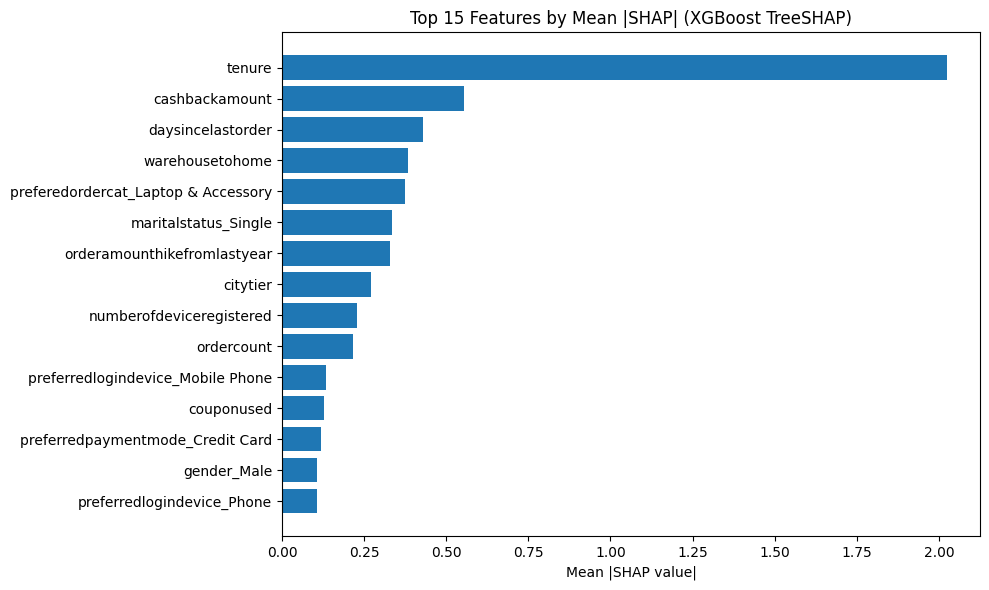

,feature,mean_abs_shap
0,tenure,2.024096
8,cashbackamount,0.555058
7,daysincelastorder,0.429034
1,warehousetohome,0.384744
22,preferedordercat_Laptop & Accessory,0.373495
12,maritalstatus_Single,0.335003
4,orderamounthikefromlastyear,0.329273
9,citytier,0.270008
3,numberofdeviceregistered,0.228964
6,ordercount,0.215169


In [132]:
# SHAP explainability for XGBoost using native TreeSHAP contributions
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

if "xgb_model" not in globals() or "X_train" not in globals() or "X_test" not in globals():
    raise NameError("Run the model training and split cells first.")

# Use a sample to keep SHAP computation fast and readable.
X_explain = X_test.sample(n=min(300, len(X_test)), random_state=42)

# Native SHAP values from XGBoost (last column is expected value / bias term).
dmatrix_explain = xgb.DMatrix(X_explain)
shap_contribs = xgb_model.get_booster().predict(dmatrix_explain, pred_contribs=True)
shap_values = shap_contribs[:, :-1]

print(f"Explain sample shape: {X_explain.shape}")
print(f"SHAP matrix shape: {shap_values.shape}")

# Global importance from mean absolute SHAP value.
shap_importance = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    shap_importance.head(15)["feature"][::-1],
    shap_importance.head(15)["mean_abs_shap"][::-1]
 )
plt.title("Top 15 Features by Mean |SHAP| (XGBoost TreeSHAP)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

display(shap_importance.head(15))

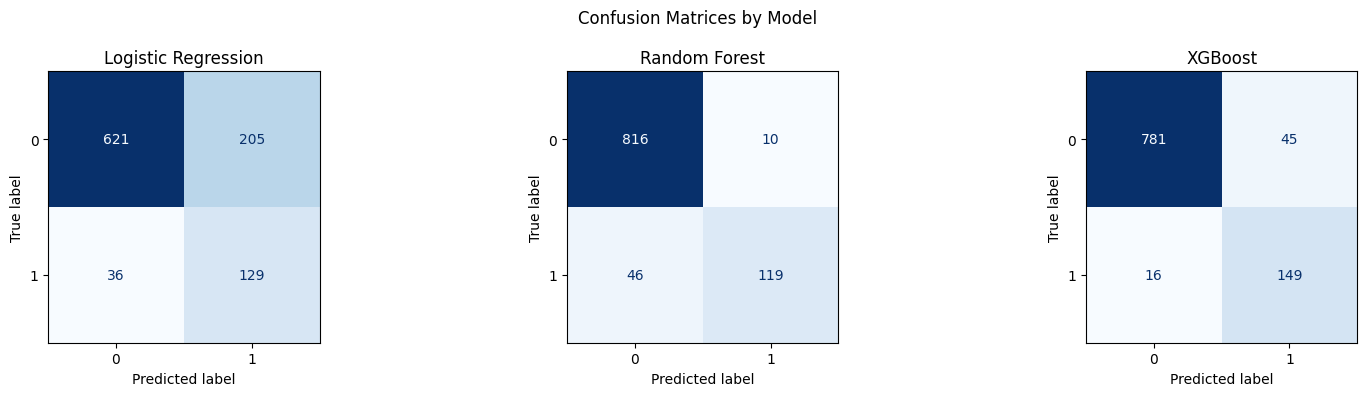

In [133]:
# Confusion Matrix (all models)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if "y_test" not in globals():
    raise NameError("Run model training and evaluation cells first.")

model_inputs = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (mdl, x_eval)) in zip(axes, model_inputs.items()):
    y_pred_cm = mdl.predict(x_eval)
    cm = confusion_matrix(y_test, y_pred_cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(name)

plt.suptitle("Confusion Matrices by Model")
plt.tight_layout()
plt.show()

In [144]:
import pickle
from pathlib import Path

artifact = {
    "model": model,
    "scaler": scaler,
    "feature_columns": list(X.columns),
    "mode_values": mode_values.to_dict() if "mode_values" in globals() else {},
    "cluster_customer_type_map": cluster_customer_type_map if "cluster_customer_type_map" in globals() else {},
}

pkl_path = Path.cwd() / "ml" / "churn_model.pkl"
pkl_path.parent.mkdir(parents=True, exist_ok=True)

with pkl_path.open("wb") as f:
    pickle.dump(artifact, f)

print(f"Saved model artifact to: {pkl_path}")

Saved model artifact to: e:\git projects\Hackathon\Kenexai-Hackathon-2k26\ml\ml\churn_model.pkl
